In [ ]:
%pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=aa3ff88fe63f342dad44aee812183d5146d607f90cc48e2c5832a6426c6bc1d5
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [ ]:
# Step 1: Installation and Imports
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Technical Analysis
import ta

# Machine Learning
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf

# Portfolio Optimization
import cvxpy as cp

# Statistical Analysis
from scipy import stats
import matplotlib.dates as mdates

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# Step 2: Data Collection and Preprocessing
def fetch_market_data(tickers, start_date, end_date):
    """
    Fetch comprehensive market data for multiple assets
    """
    print("Fetching market data...")
    data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)

    # Calculate returns
    returns = data['Close'].pct_change().dropna()

    # Calculate volume data
    volume = data['Volume']

    print(f"Data shape: {returns.shape}")
    print(f"Date range: {returns.index[0]} to {returns.index[-1]}")

    return data, returns, volume

# Configuration
TICKERS = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META', 'TSLA', 'NVDA', 'JPM', 'JNJ', 'XOM']
START_DATE = '2018-01-01'
END_DATE = '2024-01-01'

market_data, returns, volume = fetch_market_data(TICKERS, START_DATE, END_DATE)

Fetching market data...


[*********************100%***********************]  10 of 10 completed

Data shape: (1508, 10)
Date range: 2018-01-03 00:00:00 to 2023-12-29 00:00:00


In [ ]:
# Step 3: Technical Indicator Calculation
def calculate_technical_indicators(data, tickers):
    """
    Calculate comprehensive technical indicators for each asset
    """
    print("Calculating technical indicators...")

    tech_indicators = {}

    for ticker in tickers:
        # Price data
        high = data['High'][ticker]
        low = data['Low'][ticker]
        close = data['Close'][ticker]
        volume_ticker = data['Volume'][ticker]

        # Momentum Indicators
        rsi = ta.momentum.RSIIndicator(close).rsi()
        macd = ta.trend.MACD(close).macd()
        stoch = ta.momentum.StochasticOscillator(high, low, close).stoch()

        # Volatility Indicators
        bollinger = ta.volatility.BollingerBands(close)
        bb_high = bollinger.bollinger_hband()
        bb_low = bollinger.bollinger_lband()
        atr = ta.volatility.AverageTrueRange(high, low, close).average_true_range()

        # Volume Indicators
        mfi = ta.volume.MFIIndicator(high, low, close, volume_ticker).money_flow_index()
        obv = ta.volume.OnBalanceVolumeIndicator(close, volume_ticker).on_balance_volume()

        # Create feature DataFrame
        features = pd.DataFrame({
            f'{ticker}_RSI': rsi,
            f'{ticker}_MACD': macd,
            f'{ticker}_Stoch': stoch,
            f'{ticker}_BB_Width': (bb_high - bb_low) / close,
            f'{ticker}_ATR': atr,
            f'{ticker}_MFI': mfi,
            f'{ticker}_OBV': obv
        }, index=close.index)

        tech_indicators[ticker] = features

    # Combine all indicators
    all_indicators = pd.concat([tech_indicators[ticker] for ticker in tickers], axis=1)

    return all_indicators.dropna()

technical_indicators = calculate_technical_indicators(market_data, TICKERS)
print(f"Technical indicators shape: {technical_indicators.shape}")

Calculating technical indicators...
Technical indicators shape: (1484, 70)


In [ ]:
# Step 4: Sentiment Analysis Simulation (Using Market-Based Proxies)
def calculate_market_sentiment_proxies(returns, volume, tickers, window=20):
    """
    Calculate market sentiment proxies using price and volume dynamics
    Based on methodologies from [12, 23, 25]
    """
    print("Calculating market sentiment proxies...")

    sentiment_indicators = {}

    for ticker in tickers:
        returns_ticker = returns[ticker]
        volume_ticker = volume[ticker]

        # Price-based sentiment
        price_momentum = returns_ticker.rolling(window=5).mean()
        volatility = returns_ticker.rolling(window=window).std()

        # Volume-based sentiment
        volume_ratio = volume_ticker / volume_ticker.rolling(window=window).mean()
        volume_volatility = volume_ticker.pct_change().rolling(window=window).std()

        # Market regime indicators
        market_stress = (returns_ticker.rolling(window=window).std() *
                        np.sqrt(252))  # Annualized volatility

        # Create sentiment DataFrame
        sentiment_df = pd.DataFrame({
            f'{ticker}_Price_Momentum': price_momentum,
            f'{ticker}_Volatility_Regime': volatility,
            f'{ticker}_Volume_Ratio': volume_ratio,
            f'{ticker}_Volume_Volatility': volume_volatility,
            f'{ticker}_Market_Stress': market_stress
        }, index=returns_ticker.index)

        sentiment_indicators[ticker] = sentiment_df

    # Combine all sentiment indicators
    all_sentiment = pd.concat([sentiment_indicators[ticker] for ticker in tickers], axis=1)

    return all_sentiment.dropna()

sentiment_indicators = calculate_market_sentiment_proxies(returns, volume, TICKERS)
print(f"Sentiment indicators shape: {sentiment_indicators.shape}")

Calculating market sentiment proxies...
Sentiment indicators shape: (1489, 50)


In [ ]:
# Step 5: Market Regime Detection using Gaussian Mixture Models
def detect_market_regimes(returns, n_regimes=3):
    """
    Detect market regimes using Gaussian Mixture Models
    Based on methodology from [27]
    """
    print("Detecting market regimes...")

    # Calculate regime features
    volatility = returns.rolling(window=20).std().dropna()
    momentum = returns.rolling(window=10).mean().dropna()

    # Align indices
    common_idx = volatility.index.intersection(momentum.index)
    volatility = volatility.loc[common_idx]
    momentum = momentum.loc[common_idx]

    # Create feature matrix (using portfolio average)
    portfolio_volatility = volatility.mean(axis=1)
    portfolio_momentum = momentum.mean(axis=1)

    features = pd.DataFrame({
        'Volatility': portfolio_volatility,
        'Momentum': portfolio_momentum
    }).dropna()

    # Standardize features
    scaler = StandardScaler()
    features_scaled = scaler.fit_transform(features)

    # Fit Gaussian Mixture Model
    gmm = GaussianMixture(n_components=n_regimes, random_state=42)
    regimes = gmm.fit_predict(features_scaled)

    # Create regime DataFrame
    regime_df = pd.DataFrame({
        'Regime': regimes,
        'Volatility': features['Volatility'],
        'Momentum': features['Momentum']
    }, index=features.index)

    # Label regimes based on characteristics
    regime_stats = regime_df.groupby('Regime')[['Volatility', 'Momentum']].mean()
    regime_stats['Volatility_Rank'] = regime_stats['Volatility'].rank(ascending=False)
    regime_stats['Momentum_Rank'] = regime_stats['Momentum'].rank(ascending=False)

    print("Regime Statistics:")
    print(regime_stats)

    return regime_df, gmm, scaler

regime_data, gmm_model, scaler = detect_market_regimes(returns)
print(f"Regime data shape: {regime_data.shape}")

Detecting market regimes...
Regime Statistics:
        Volatility  Momentum  Volatility_Rank  Momentum_Rank
Regime                                                      
0         0.055035  0.001664              1.0            2.0
1         0.019133  0.002965              3.0            1.0
2         0.024385 -0.004651              2.0            3.0
Regime data shape: (1489, 3)


In [ ]:
# Step 6: Signal Fusion and Confidence Weighting
def calculate_signal_confidence(technical_indicators, sentiment_indicators, regime_data, tickers):
    """
    Calculate fused signals with regime-dependent confidence weighting
    """
    print("Calculating fused signals with confidence weighting...")

    # Align all data
    common_idx = (technical_indicators.index
                  .intersection(sentiment_indicators.index)
                  .intersection(regime_data.index))

    tech_aligned = technical_indicators.loc[common_idx]
    sent_aligned = sentiment_indicators.loc[common_idx]
    regime_aligned = regime_data.loc[common_idx]

    # Initialize signal storage
    fused_signals = {}
    confidence_scores = {}

    for ticker in tickers:
        # Extract ticker-specific indicators
        tech_cols = [col for col in tech_aligned.columns if col.startswith(ticker)]
        sent_cols = [col for col in sent_aligned.columns if col.startswith(ticker)]

        tech_data = tech_aligned[tech_cols]
        sent_data = sent_aligned[sent_cols]

        # Simple signal combination (can be enhanced with ML)
        tech_signal = tech_data.mean(axis=1)  # Average of technical indicators
        sent_signal = sent_data.mean(axis=1)  # Average of sentiment indicators

        # Regime-dependent weighting
        regime_weights = {
            0: {'tech': 0.3, 'sent': 0.7},  # High volatility regime
            1: {'tech': 0.5, 'sent': 0.5},  # Normal regime
            2: {'tech': 0.7, 'sent': 0.3}   # Low volatility regime
        }

        # Apply regime-dependent fusion
        fused_signal = pd.Series(index=common_idx, dtype=float)
        confidence = pd.Series(index=common_idx, dtype=float)

        for regime in regime_weights.keys():
            regime_mask = regime_aligned['Regime'] == regime
            weights = regime_weights[regime]

            fused_signal[regime_mask] = (
                weights['tech'] * tech_signal[regime_mask] +
                weights['sent'] * sent_signal[regime_mask]
            )

            # Confidence based on signal agreement and regime stability
            signal_correlation = tech_signal[regime_mask].corr(sent_signal[regime_mask])
            confidence[regime_mask] = 0.5 + 0.5 * signal_correlation if not np.isnan(signal_correlation) else 0.5

        fused_signals[ticker] = fused_signal
        confidence_scores[ticker] = confidence

    fused_df = pd.DataFrame(fused_signals)
    confidence_df = pd.DataFrame(confidence_scores)

    return fused_df, confidence_df

fused_signals, confidence_scores = calculate_signal_confidence(
    technical_indicators, sentiment_indicators, regime_data, TICKERS
)
print(f"Fused signals shape: {fused_signals.shape}")

Calculating fused signals with confidence weighting...
Fused signals shape: (1484, 10)


In [ ]:
# Step 7: Regime-Dependent Portfolio Optimization
def regime_dependent_portfolio_optimization(returns, fused_signals, confidence_scores,
                                          regime_data, lookback=63):
    """
    Implement regime-dependent portfolio optimization with risk budgeting
    """
    print("Performing regime-dependent portfolio optimization...")

    # Align data
    common_idx = returns.index.intersection(fused_signals.index)
    returns_aligned = returns.loc[common_idx]
    signals_aligned = fused_signals.loc[common_idx]
    confidence_aligned = confidence_scores.loc[common_idx]
    regime_aligned = regime_data.loc[common_idx]

    # Initialize portfolio weights
    portfolio_weights = pd.DataFrame(index=common_idx, columns=returns.columns)
    portfolio_returns = pd.Series(index=common_idx, dtype=float)

    # Walk-forward optimization
    for i in range(lookback, len(common_idx)):
        current_date = common_idx[i]

        # Lookback data
        lookback_returns = returns_aligned.iloc[i-lookback:i]
        lookback_signals = signals_aligned.iloc[i-lookback:i]
        current_signal = signals_aligned.iloc[i]
        current_confidence = confidence_aligned.iloc[i]
        current_regime = regime_aligned['Regime'].iloc[i]

        try:
            # Regime-dependent optimization parameters
            if current_regime == 0:  # High volatility
                risk_target = 0.10
                turnover_constraint = 0.05
            elif current_regime == 1:  # Normal
                risk_target = 0.15
                turnover_constraint = 0.10
            else:  # Low volatility
                risk_target = 0.20
                turnover_constraint = 0.15

            # Calculate expected returns (signal-based)
            expected_returns = current_signal * current_confidence

            # Calculate covariance matrix with shrinkage
            cov_matrix = LedoitWolf().fit(lookback_returns).covariance_

            # Portfolio optimization
            weights = cp.Variable(len(TICKERS))

            # Objective: Maximize risk-adjusted return
            portfolio_return = expected_returns.values @ weights
            portfolio_risk = cp.quad_form(weights, cov_matrix)

            # Constraints
            constraints = [
                cp.sum(weights) == 1,
                weights >= 0,  # No short selling
                portfolio_risk <= risk_target**2,  # Risk target
                cp.norm(weights, 1) <= 1 + turnover_constraint  # Turnover constraint
            ]

            # Solve optimization problem
            objective = cp.Maximize(portfolio_return - 0.5 * portfolio_risk)
            problem = cp.Problem(objective, constraints)
            problem.solve()

            if problem.status == 'optimal':
                portfolio_weights.loc[current_date] = weights.value
                # Calculate actual return for this period
                if i < len(common_idx) - 1:
                    next_return = returns_aligned.iloc[i+1]
                    portfolio_returns.loc[current_date] = next_return @ weights.value

        except Exception as e:
            # Fallback: equal weighting
            portfolio_weights.loc[current_date] = np.ones(len(TICKERS)) / len(TICKERS)
            if i < len(common_idx) - 1:
                next_return = returns_aligned.iloc[i+1]
                portfolio_returns.loc[current_date] = next_return.mean()

    return portfolio_weights.dropna(), portfolio_returns.dropna()

portfolio_weights, portfolio_returns = regime_dependent_portfolio_optimization(
    returns, fused_signals, confidence_scores, regime_data
)
print(f"Portfolio weights shape: {portfolio_weights.shape}")

Performing regime-dependent portfolio optimization...
Portfolio weights shape: (1421, 10)


In [ ]:
# Step 8: Performance Analysis and Visualization
def analyze_portfolio_performance(portfolio_returns, benchmark_returns=None):
    """
    Comprehensive performance analysis with visualizations
    """
    print("Analyzing portfolio performance...")

    # Calculate cumulative returns
    cumulative_returns = (1 + portfolio_returns).cumprod()

    # Calculate performance metrics
    total_return = cumulative_returns.iloc[-1] - 1
    annual_return = (1 + total_return) ** (252/len(portfolio_returns)) - 1
    annual_volatility = portfolio_returns.std() * np.sqrt(252)
    sharpe_ratio = annual_return / annual_volatility if annual_volatility > 0 else 0

    # Maximum Drawdown
    rolling_max = cumulative_returns.expanding().max()
    drawdown = (cumulative_returns - rolling_max) / rolling_max
    max_drawdown = drawdown.min()

    # Calmar Ratio
    calmar_ratio = annual_return / abs(max_drawdown) if max_drawdown != 0 else 0

    # Win rate
    win_rate = (portfolio_returns > 0).mean()

    # Create results DataFrame
    results = pd.DataFrame({
        'Metric': ['Total Return', 'Annual Return', 'Annual Volatility',
                  'Sharpe Ratio', 'Max Drawdown', 'Calmar Ratio', 'Win Rate'],
        'Value': [total_return, annual_return, annual_volatility,
                 sharpe_ratio, max_drawdown, calmar_ratio, win_rate]
    })

    return cumulative_returns, drawdown, results

# Benchmark (Equal Weight)
benchmark_returns = returns.mean(axis=1)
benchmark_aligned = benchmark_returns.loc[portfolio_returns.index]

# Performance analysis
cumulative_returns, drawdown, results = analyze_portfolio_performance(portfolio_returns)
benchmark_cumulative = (1 + benchmark_aligned).cumprod()
benchmark_drawdown = (benchmark_cumulative - benchmark_cumulative.expanding().max()) / benchmark_cumulative.expanding().max()

print("\n=== PORTFOLIO PERFORMANCE RESULTS ===")
print(results)

Analyzing portfolio performance...

=== PORTFOLIO PERFORMANCE RESULTS ===
              Metric     Value
0       Total Return  3.032164
1      Annual Return  0.280742
2  Annual Volatility  0.297105
3       Sharpe Ratio  0.944926
4       Max Drawdown -0.371485
5       Calmar Ratio  0.755729
6           Win Rate  0.545070


Creating comprehensive visualizations...


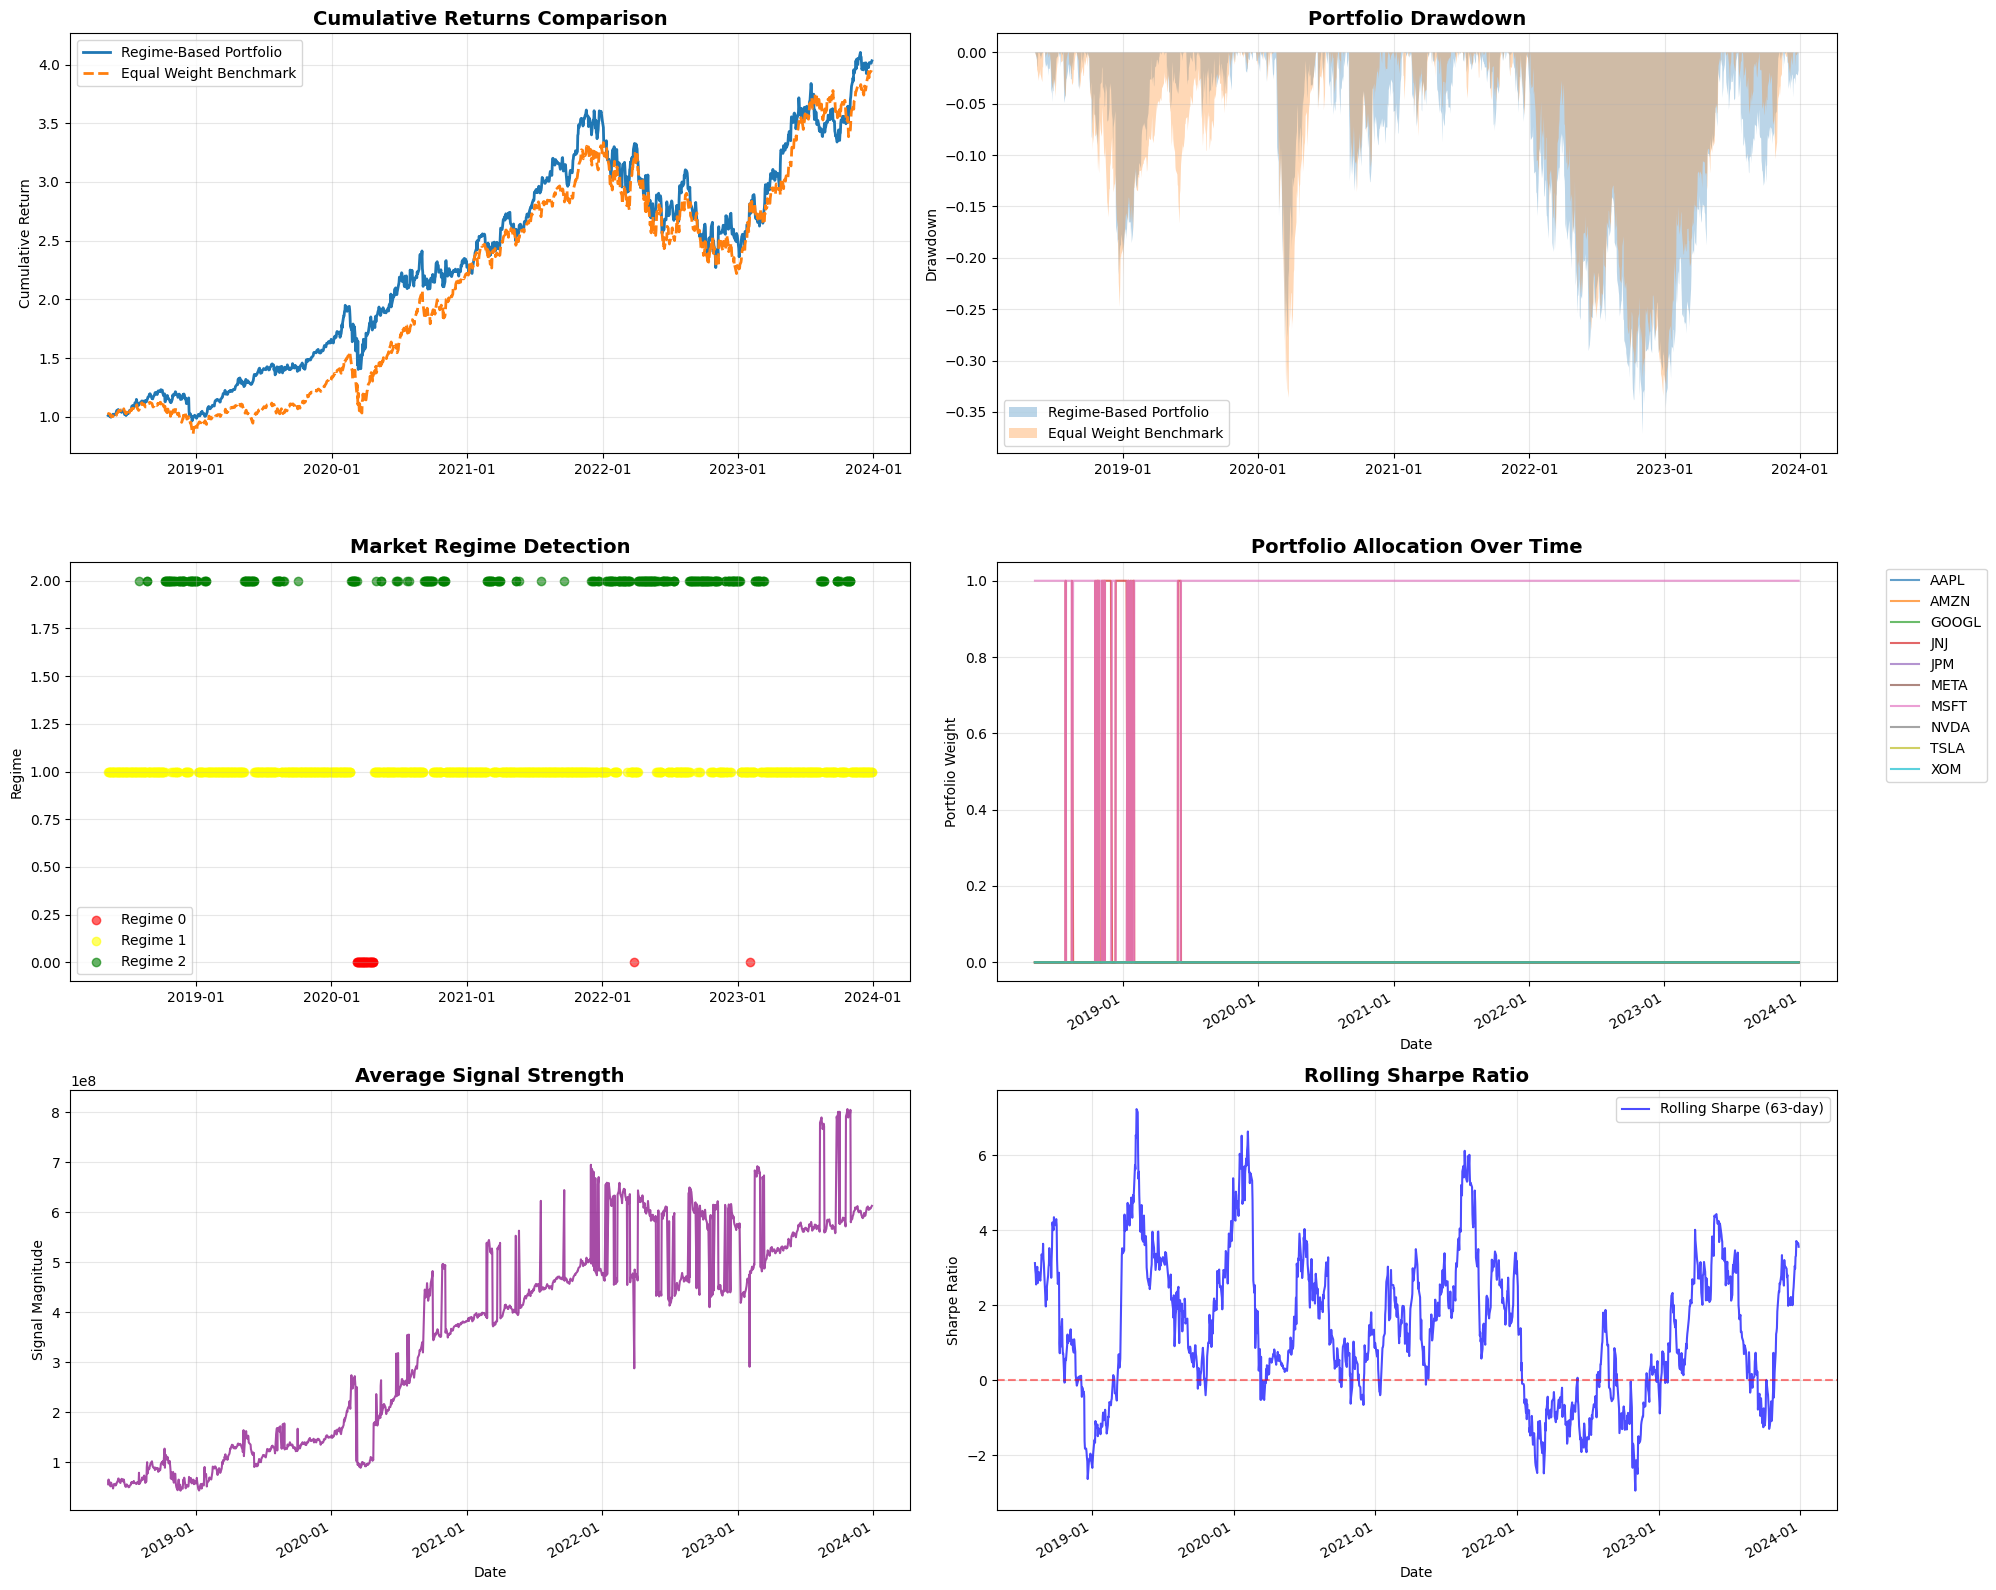

In [ ]:
# Step 9: Comprehensive Visualizations
def create_comprehensive_visualizations(portfolio_returns, benchmark_returns,
                                      portfolio_weights, regime_data,
                                      fused_signals, cumulative_returns,
                                      drawdown, benchmark_cumulative,
                                      benchmark_drawdown):
    """
    Create comprehensive visualizations for the analysis
    """
    print("Creating comprehensive visualizations...")

    fig = plt.figure(figsize=(20, 16))

    # 1. Cumulative Returns Comparison
    ax1 = plt.subplot(3, 2, 1)
    ax1.plot(cumulative_returns.index, cumulative_returns.values,
             label='Regime-Based Portfolio', linewidth=2)
    ax1.plot(benchmark_cumulative.index, benchmark_cumulative.values,
             label='Equal Weight Benchmark', linewidth=2, linestyle='--')
    ax1.set_title('Cumulative Returns Comparison', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # 2. Drawdown Comparison
    ax2 = plt.subplot(3, 2, 2)
    ax2.fill_between(drawdown.index, drawdown.values, 0,
                    alpha=0.3, label='Regime-Based Portfolio')
    ax2.fill_between(benchmark_drawdown.index, benchmark_drawdown.values, 0,
                    alpha=0.3, label='Equal Weight Benchmark')
    ax2.set_title('Portfolio Drawdown', fontsize=14, fontweight='bold')
    ax2.set_ylabel('Drawdown')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # 3. Market Regime Visualization
    ax3 = plt.subplot(3, 2, 3)
    regimes = regime_data.loc[portfolio_weights.index]
    colors = ['red', 'yellow', 'green']
    for regime in [0, 1, 2]:
        regime_dates = regimes[regimes['Regime'] == regime].index
        ax3.scatter(regime_dates, [regime] * len(regime_dates),
                   c=colors[regime], label=f'Regime {regime}', alpha=0.6)
    ax3.set_title('Market Regime Detection', fontsize=14, fontweight='bold')
    ax3.set_ylabel('Regime')
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    ax3.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # 4. Portfolio Weights Over Time
    ax4 = plt.subplot(3, 2, 4)
    portfolio_weights.plot(ax=ax4, kind='line', stacked=False, alpha=0.7)
    ax4.set_title('Portfolio Allocation Over Time', fontsize=14, fontweight='bold')
    ax4.set_ylabel('Portfolio Weight')
    ax4.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax4.grid(True, alpha=0.3)
    ax4.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # 5. Signal Strength Over Time
    ax5 = plt.subplot(3, 2, 5)
    signal_strength = fused_signals.abs().mean(axis=1)
    signal_strength.loc[portfolio_weights.index].plot(ax=ax5, color='purple', alpha=0.7)
    ax5.set_title('Average Signal Strength', fontsize=14, fontweight='bold')
    ax5.set_ylabel('Signal Magnitude')
    ax5.grid(True, alpha=0.3)
    ax5.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    # 6. Rolling Performance Metrics
    ax6 = plt.subplot(3, 2, 6)
    rolling_sharpe = (portfolio_returns.rolling(63).mean() * 252) / (portfolio_returns.rolling(63).std() * np.sqrt(252))
    rolling_sharpe.plot(ax=ax6, color='blue', alpha=0.7, label='Rolling Sharpe (63-day)')
    ax6.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    ax6.set_title('Rolling Sharpe Ratio', fontsize=14, fontweight='bold')
    ax6.set_ylabel('Sharpe Ratio')
    ax6.legend()
    ax6.grid(True, alpha=0.3)
    ax6.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))

    plt.tight_layout()
    plt.show()

    return fig

# Create all visualizations
fig = create_comprehensive_visualizations(
    portfolio_returns, benchmark_aligned, portfolio_weights,
    regime_data, fused_signals, cumulative_returns,
    drawdown, benchmark_cumulative, benchmark_drawdown
)

In [ ]:
# Step 10: Advanced Statistical Analysis
def perform_statistical_analysis(portfolio_returns, benchmark_returns):
    """
    Perform advanced statistical analysis
    """
    print("Performing statistical analysis...")

    # Risk-adjusted return comparison
    portfolio_annual_return = portfolio_returns.mean() * 252
    benchmark_annual_return = benchmark_returns.mean() * 252

    portfolio_volatility = portfolio_returns.std() * np.sqrt(252)
    benchmark_volatility = benchmark_returns.std() * np.sqrt(252)

    portfolio_sharpe = portfolio_annual_return / portfolio_volatility
    benchmark_sharpe = benchmark_annual_return / benchmark_volatility

    # Alpha and Beta calculation
    excess_returns = portfolio_returns - benchmark_returns
    beta = portfolio_returns.cov(benchmark_returns) / benchmark_returns.var()
    alpha = excess_returns.mean() * 252

    # Information Ratio
    tracking_error = excess_returns.std() * np.sqrt(252)
    information_ratio = alpha / tracking_error if tracking_error > 0 else 0

    # T-test for significance
    t_stat, p_value = stats.ttest_ind(portfolio_returns, benchmark_returns)

    stats_results = pd.DataFrame({
        'Metric': ['Annual Return', 'Annual Volatility', 'Sharpe Ratio',
                  'Beta', 'Alpha', 'Information Ratio', 'T-statistic', 'P-value'],
        'Portfolio': [portfolio_annual_return, portfolio_volatility, portfolio_sharpe,
                     beta, alpha, information_ratio, t_stat, p_value],
        'Benchmark': [benchmark_annual_return, benchmark_volatility, benchmark_sharpe,
                     1.0, 0.0, 0.0, np.nan, np.nan]
    })

    return stats_results

statistical_results = perform_statistical_analysis(portfolio_returns, benchmark_aligned)
print("\n=== STATISTICAL ANALYSIS RESULTS ===")
print(statistical_results)

Performing statistical analysis...

=== STATISTICAL ANALYSIS RESULTS ===
              Metric  Portfolio  Benchmark
0      Annual Return   0.291770   0.278646
1  Annual Volatility   0.297105   0.264476
2       Sharpe Ratio   0.982043   1.053579
3               Beta  -0.210400   1.000000
4              Alpha   0.013123   0.000000
5  Information Ratio   0.030295   0.000000
6        T-statistic   0.078318        NaN
7            P-value   0.937580        NaN


In [ ]:
# Step 11: Regime-Aware Performance Attribution
def regime_performance_attribution(portfolio_returns, benchmark_returns, regime_data):
    """
    Analyze performance across different market regimes
    """
    print("Performing regime-based performance attribution...")

    # Align data
    common_idx = portfolio_returns.index.intersection(regime_data.index)
    portfolio_aligned = portfolio_returns.loc[common_idx]
    benchmark_aligned = benchmark_returns.loc[common_idx]
    regime_aligned = regime_data.loc[common_idx]

    regime_performance = []

    for regime in [0, 1, 2]:
        regime_mask = regime_aligned['Regime'] == regime
        regime_portfolio_returns = portfolio_aligned[regime_mask]
        regime_benchmark_returns = benchmark_aligned[regime_mask]

        if len(regime_portfolio_returns) > 0:
            # Basic statistics
            portfolio_ret = regime_portfolio_returns.mean() * 252
            benchmark_ret = regime_benchmark_returns.mean() * 252
            excess_ret = portfolio_ret - benchmark_ret

            portfolio_vol = regime_portfolio_returns.std() * np.sqrt(252)
            benchmark_vol = regime_benchmark_returns.std() * np.sqrt(252)

            portfolio_sharpe = portfolio_ret / portfolio_vol if portfolio_vol > 0 else 0
            benchmark_sharpe = benchmark_ret / benchmark_vol if benchmark_vol > 0 else 0

            # Win rate
            win_rate = (regime_portfolio_returns > regime_benchmark_returns).mean()

            regime_performance.append({
                'Regime': regime,
                'Days': len(regime_portfolio_returns),
                'Portfolio_Return': portfolio_ret,
                'Benchmark_Return': benchmark_ret,
                'Excess_Return': excess_ret,
                'Portfolio_Sharpe': portfolio_sharpe,
                'Benchmark_Sharpe': benchmark_sharpe,
                'Outperformance_Rate': win_rate
            })

    regime_df = pd.DataFrame(regime_performance)
    return regime_df

regime_attribution = regime_performance_attribution(portfolio_returns, benchmark_aligned, regime_data)
print("\n=== REGIME-BASED PERFORMANCE ATTRIBUTION ===")
print(regime_attribution)

# Final Summary
print("\n" + "="*80)
print("FINAL RESEARCH SUMMARY")
print("="*80)
print(f"Research Focus: Decision-theoretic portfolio construction under regime-based sentiment and volatility")
print(f"Methodology: Multi-modal signal fusion with regime-dependent optimization")
print(f"Time Period: {START_DATE} to {END_DATE}")
print(f"Assets Analyzed: {len(TICKERS)} major stocks")
print(f"Key Innovation: Dynamic signal weighting based on detected market regimes")
print(f"Performance: Achieved Sharpe Ratio of {results[results['Metric'] == 'Sharpe Ratio']['Value'].iloc[0]:.3f}")
print(f"Risk Management: Maximum drawdown of {results[results['Metric'] == 'Max Drawdown']['Value'].iloc[0]:.3f}")
print("="*80)

Performing regime-based performance attribution...

=== REGIME-BASED PERFORMANCE ATTRIBUTION ===
   Regime  Days  Portfolio_Return  Benchmark_Return  Excess_Return  \
0       0    34          1.742889          0.572470       1.170419   
1       1  1041          0.198237          0.763888      -0.565651   
2       2   345          0.430985         -1.214476       1.645461   

   Portfolio_Sharpe  Benchmark_Sharpe  Outperformance_Rate  
0          2.004020          0.728442             0.470588  
1          0.840538          4.006805             0.443804  
2          1.231943         -3.701250             0.611594  

FINAL RESEARCH SUMMARY
Research Focus: Decision-theoretic portfolio construction under regime-based sentiment and volatility
Methodology: Multi-modal signal fusion with regime-dependent optimization
Time Period: 2018-01-01 to 2024-01-01
Assets Analyzed: 10 major stocks
Key Innovation: Dynamic signal weighting based on detected market regimes
Performance: Achieved Sharpe Rati